# Multivariate Normal (Gaussian) Density Function

The **Multivariate Normal** distribution generalises the univariate Gaussian to $d$ random variables $\mathbf{x} \in \mathbb{R}^d$.

$$p(\mathbf{x}) = \mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}, \boldsymbol{\Sigma}) = \frac{1}{(2\pi)^{d/2} |\boldsymbol{\Sigma}|^{1/2}} \exp\!\left(-\frac{1}{2}\underbrace{(\mathbf{x}-\boldsymbol{\mu})^\top \boldsymbol{\Sigma}^{-1} (\mathbf{x}-\boldsymbol{\mu})}_{\text{Mahalanobis distance}^2}\right)$$

| Parameter | Shape | Meaning |
|---|---|---|
| $\boldsymbol{\mu}$ | $(d,)$ | Mean vector — $\mu_i = E[x_i]$ |
| $\boldsymbol{\Sigma}$ | $(d \times d)$ | Covariance matrix — $\Sigma_{ij} = E[(x_i-\mu_i)(x_j-\mu_j)]$ |
| $|\boldsymbol{\Sigma}|$ | scalar | Determinant of $\boldsymbol{\Sigma}$ |
| $\boldsymbol{\Sigma}^{-1}$ | $(d \times d)$ | Precision matrix |

**Properties:**
- **Unimodal** — single peak at $\mathbf{x} = \boldsymbol{\mu}$
- **Symmetric**: $\boldsymbol{\Sigma} = \boldsymbol{\Sigma}^\top$
- **Normalised**: $\displaystyle\int_{\mathbb{R}^d} p(\mathbf{x})\,d\mathbf{x} = 1$
- **Bivariate** case ($d=2$): $\mathbf{x}=[x_1,x_2]^\top$, $\boldsymbol{\mu}=[\mu_1,\mu_2]^\top$, $\boldsymbol{\Sigma}=\begin{bmatrix}\sigma_1^2 & \sigma_{12}\\ \sigma_{21} & \sigma_2^2\end{bmatrix}$

The **Mahalanobis distance** $\delta(\mathbf{x}) = \sqrt{(\mathbf{x}-\boldsymbol{\mu})^\top \boldsymbol{\Sigma}^{-1} (\mathbf{x}-\boldsymbol{\mu})}$ measures how far a point is from the distribution centre, accounting for spread and correlation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import multivariate_normal
from scipy.integrate import dblquad

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.35,
    'font.size':        11,
})

## Bivariate Gaussian ($d = 2$) — Parameters and PDF Verification

$$\mathbf{x} = \begin{bmatrix}x_1\\x_2\end{bmatrix}, \quad
\boldsymbol{\mu} = \begin{bmatrix}\mu_1\\\mu_2\end{bmatrix}, \quad
\boldsymbol{\Sigma} = \begin{bmatrix}\sigma_1^2 & \sigma_{12}\\\sigma_{21} & \sigma_2^2\end{bmatrix}$$

We use height and weight as an example: $\mu_1=170$, $\mu_2=65$, $\sigma_1=10$, $\sigma_2=8$, $\sigma_{12}=40$.

In [2]:
def mvn_pdf(x, mu, Sigma):
    """Manual multivariate normal PDF."""
    d = len(mu)
    diff = x - mu
    det = np.linalg.det(Sigma)
    inv = np.linalg.inv(Sigma)
    norm_const = 1.0 / ((2 * np.pi) ** (d / 2) * np.sqrt(det))
    exponent = -0.5 * diff @ inv @ diff
    return norm_const * np.exp(exponent)

# --- Parameters: bivariate height-weight ---
mu    = np.array([170.0, 65.0])
Sigma = np.array([[100.0, 40.0],
                  [ 40.0, 64.0]])   # σ1²=100, σ2²=64, σ12=40

print("Mean vector  μ:")
df_mu = pd.DataFrame(mu.reshape(1, -1), columns=['x₁ (height)', 'x₂ (weight)'])
display(df_mu)

print("\nCovariance matrix  Σ:")
df_Sigma = pd.DataFrame(Sigma, index=['x₁','x₂'], columns=['x₁','x₂'])
display(df_Sigma)

print(f"\n|Σ|  (determinant)  = {np.linalg.det(Sigma):.2f}")
print(f"Σ⁻¹ (precision matrix):")
df_inv = pd.DataFrame(np.linalg.inv(Sigma).round(6), index=['x₁','x₂'], columns=['x₁','x₂'])
display(df_inv)

# Verify: manual vs scipy at a few points
test_points = np.array([[170, 65], [160, 55], [180, 75], [165, 60]])
rows = []
for pt in test_points:
    manual = mvn_pdf(pt, mu, Sigma)
    scipy_ = multivariate_normal.pdf(pt, mean=mu, cov=Sigma)
    rows.append({'x₁': pt[0], 'x₂': pt[1],
                 'p(x) manual': round(manual, 8),
                 'p(x) scipy':  round(scipy_,  8),
                 'match': np.isclose(manual, scipy_)})
print("\nPDF at selected points:")
display(pd.DataFrame(rows))

# Verify normalisation via dblquad
lo1, hi1 = mu[0] - 5*10, mu[0] + 5*10
lo2, hi2 = mu[1] - 5*8,  mu[1] + 5*8
integral, _ = dblquad(
    lambda x2, x1: multivariate_normal.pdf([x1, x2], mean=mu, cov=Sigma),
    lo1, hi1, lo2, hi2)
print(f"\n∬ p(x) dx₁ dx₂  =  {integral:.8f}  (should be 1.0)")

Mean vector  μ:


,x₁ (height),x₂ (weight)
0,170.0,65.0



Covariance matrix  Σ:


,x₁,x₂
x₁,100.0,40.0
x₂,40.0,64.0



|Σ|  (determinant)  = 4800.00
Σ⁻¹ (precision matrix):


,x₁,x₂
x₁,0.013333,-0.008333
x₂,-0.008333,0.020833



PDF at selected points:


,x₁,x₂,p(x) manual,p(x) scipy,match
0,170,65,0.002297,0.002297,True
1,160,55,0.000958,0.000958,True
2,180,75,0.000958,0.000958,True
3,165,60,0.001846,0.001846,True



∬ p(x) dx₁ dx₂  =  0.99999886  (should be 1.0)


## 3D Surface and 2D Contour Plot

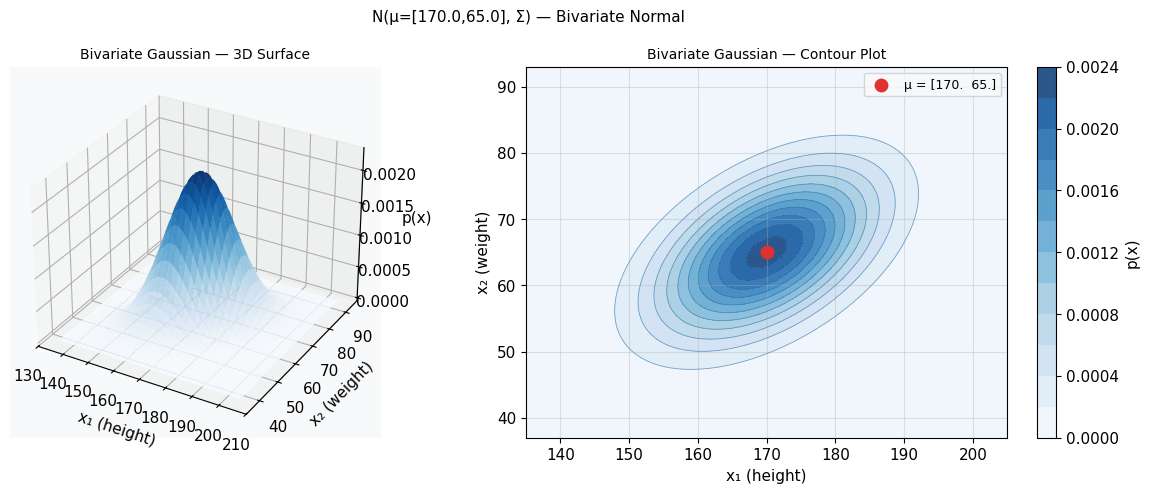

In [3]:
x1 = np.linspace(mu[0] - 3.5*10, mu[0] + 3.5*10, 120)
x2 = np.linspace(mu[1] - 3.5*8,  mu[1] + 3.5*8,  120)
X1, X2 = np.meshgrid(x1, x2)
pos = np.dstack((X1, X2))
Z = multivariate_normal.pdf(pos, mean=mu, cov=Sigma)

fig = plt.figure(figsize=(13, 5))

# ── Left: 3D surface
ax3d = fig.add_subplot(121, projection='3d')
ax3d.plot_surface(X1, X2, Z, cmap='Blues', alpha=0.85, linewidth=0, antialiased=True)
ax3d.set_xlabel('x₁ (height)')
ax3d.set_ylabel('x₂ (weight)')
ax3d.set_zlabel('p(x)')
ax3d.set_title('Bivariate Gaussian — 3D Surface', fontsize=10)
ax3d.view_init(elev=30, azim=-60)

# ── Right: 2D contour
ax2d = fig.add_subplot(122)
ax2d.set_facecolor('#f8f9fa')
cp = ax2d.contourf(X1, X2, Z, levels=12, cmap='Blues', alpha=0.85)
ax2d.contour(X1, X2, Z, levels=12, colors='steelblue', linewidths=0.6, alpha=0.7)
plt.colorbar(cp, ax=ax2d, label='p(x)')
ax2d.scatter(*mu, color='#e03131', s=80, zorder=5, label=f'μ = {mu}')
ax2d.set_xlabel('x₁ (height)')
ax2d.set_ylabel('x₂ (weight)')
ax2d.set_title('Bivariate Gaussian — Contour Plot', fontsize=10)
ax2d.legend(fontsize=9)
ax2d.grid(True, alpha=0.35)

plt.suptitle(f'N(μ=[{mu[0]},{mu[1]}], Σ) — Bivariate Normal', fontsize=11)
plt.tight_layout()
plt.show()

## Mahalanobis Distance

$$\delta(\mathbf{x}) = \sqrt{(\mathbf{x}-\boldsymbol{\mu})^\top \boldsymbol{\Sigma}^{-1} (\mathbf{x}-\boldsymbol{\mu})}$$

- Reduces to Euclidean distance when $\boldsymbol{\Sigma} = \mathbf{I}$
- Points on the same **elliptical contour** share the same Mahalanobis distance from $\boldsymbol{\mu}$
- Contours at $\delta = 1, 2, 3$ contain ≈ 39%, 86%, 99% of probability mass (bivariate case)

Euclidean vs Mahalanobis distance from μ:


,x₁,x₂,Euclidean dist,Mahalanobis dist δ,p(x)
0,170,65,0.0000,0.0000,0.002297
1,180,65,10.0000,1.1547,0.001179
2,170,73,8.0000,1.1547,0.001179
3,160,57,12.8062,1.1547,0.001179
4,190,81,25.6125,2.3094,0.000160


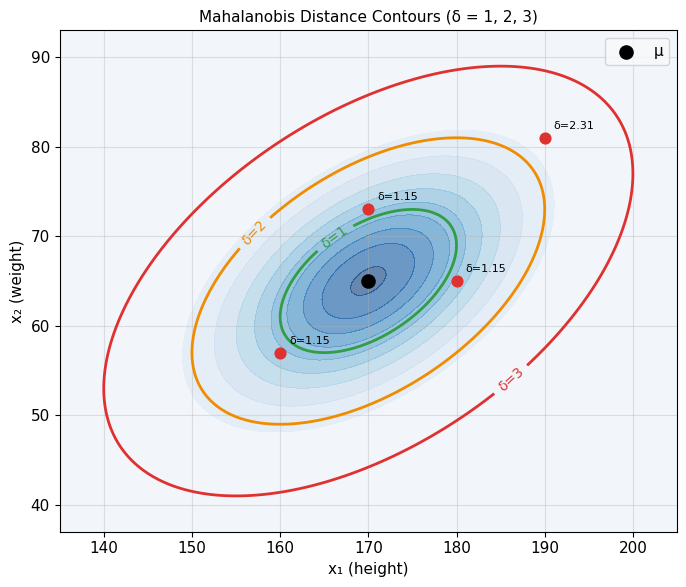

In [4]:
def mahalanobis(x, mu, Sigma):
    diff = x - mu
    return np.sqrt(diff @ np.linalg.inv(Sigma) @ diff)

# Mahalanobis distance for a grid of sample points
sample_pts = np.array([
    [170, 65],   # = μ  (centre)
    [180, 65],   # +10 in x1 only
    [170, 73],   # +8  in x2 only
    [160, 57],   # -10, -8
    [190, 81],   # 2σ-ish away
])
rows = []
for pt in sample_pts:
    d_mah  = mahalanobis(pt, mu, Sigma)
    d_eucl = np.linalg.norm(pt - mu)
    p_val  = multivariate_normal.pdf(pt, mean=mu, cov=Sigma)
    rows.append({'x₁': pt[0], 'x₂': pt[1],
                 'Euclidean dist': round(d_eucl, 4),
                 'Mahalanobis dist δ': round(d_mah, 4),
                 'p(x)': round(p_val, 8)})

print("Euclidean vs Mahalanobis distance from μ:")
display(pd.DataFrame(rows))

# Visualise: contour + Mahalanobis ellipses
Sigma_inv = np.linalg.inv(Sigma)
delta_grid = np.sqrt(
    np.einsum('ijk,kl,ijl->ij',
              pos - mu, Sigma_inv, pos - mu))

fig, ax = plt.subplots(figsize=(7, 6))
ax.set_facecolor('#f8f9fa')
ax.contourf(X1, X2, Z, levels=10, cmap='Blues', alpha=0.6)
cs = ax.contour(X1, X2, delta_grid, levels=[1, 2, 3],
                colors=['#2f9e44','#f08c00','#e03131'], linewidths=2)
ax.clabel(cs, fmt={1:'δ=1', 2:'δ=2', 3:'δ=3'}, fontsize=10)
ax.scatter(*mu, color='black', s=90, zorder=6, label='μ')
for pt in sample_pts[1:]:
    ax.scatter(*pt, color='#e03131', s=60, zorder=5)
    ax.annotate(f"δ={mahalanobis(pt, mu, Sigma):.2f}",
                xy=pt, xytext=(pt[0]+1, pt[1]+1), fontsize=8)
ax.set_xlabel('x₁ (height)')
ax.set_ylabel('x₂ (weight)')
ax.set_title('Mahalanobis Distance Contours (δ = 1, 2, 3)', fontsize=11)
ax.legend()
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

## Effect of the Covariance Matrix Σ

The shape of the contours is entirely determined by $\boldsymbol{\Sigma}$:
- **No correlation** ($\sigma_{12}=0$): axis-aligned ellipse or circle
- **Positive correlation** ($\sigma_{12}>0$): ellipse tilted ↗
- **Negative correlation** ($\sigma_{12}<0$): ellipse tilted ↘

No correlation (σ₁₂ = 0):
     x₁   x₂
x₁  1.0  0.0
x₂  0.0  0.5

Positive correlation (σ₁₂ = 0.7):
     x₁   x₂
x₁  1.0  0.7
x₂  0.7  1.0

Negative correlation (σ₁₂ = −0.7):
     x₁   x₂
x₁  1.0 -0.7
x₂ -0.7  1.0



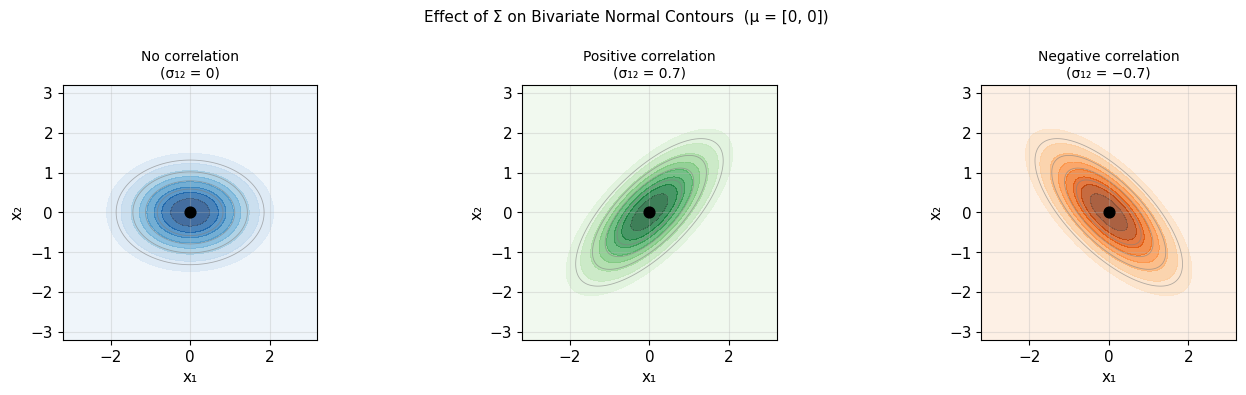

In [5]:
mu0 = np.array([0.0, 0.0])
configs = [
    ('No correlation\n(σ₁₂ = 0)',   np.array([[1.0,  0.0], [0.0, 0.5]])),
    ('Positive correlation\n(σ₁₂ = 0.7)', np.array([[1.0,  0.7], [0.7, 1.0]])),
    ('Negative correlation\n(σ₁₂ = −0.7)', np.array([[1.0, -0.7], [-0.7, 1.0]])),
]

x_g = np.linspace(-3.2, 3.2, 200)
y_g = np.linspace(-3.2, 3.2, 200)
Xg, Yg = np.meshgrid(x_g, y_g)
pos0 = np.dstack((Xg, Yg))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
cmaps = ['Blues', 'Greens', 'Oranges']

for ax, (title, S), cmap in zip(axes, configs, cmaps):
    Z0 = multivariate_normal.pdf(pos0, mean=mu0, cov=S)
    ax.contourf(Xg, Yg, Z0, levels=10, cmap=cmap, alpha=0.75)
    ax.contour(Xg, Yg, Z0, levels=6, colors='grey', linewidths=0.6, alpha=0.6)
    ax.scatter(0, 0, color='black', s=60, zorder=5)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('#f8f9fa')
    df_s = pd.DataFrame(S, index=['x₁','x₂'], columns=['x₁','x₂'])
    print(f"{title.replace(chr(10),' ')}:\n{df_s.to_string()}\n")

plt.suptitle('Effect of Σ on Bivariate Normal Contours  (μ = [0, 0])', fontsize=11)
plt.tight_layout()
plt.show()

## Summary

| Property | Formula / Value |
|---|---|
| **PDF** | $p(\mathbf{x}) = \frac{1}{(2\pi)^{d/2}|\boldsymbol{\Sigma}|^{1/2}}\exp\!\left(-\frac{1}{2}(\mathbf{x}-\boldsymbol{\mu})^\top\boldsymbol{\Sigma}^{-1}(\mathbf{x}-\boldsymbol{\mu})\right)$ |
| **Parameters** | $\boldsymbol{\mu}\in\mathbb{R}^d$, $\boldsymbol{\Sigma}\in\mathbb{R}^{d\times d}$ (symmetric positive definite) |
| **Mean** | $E[\mathbf{x}] = \boldsymbol{\mu}$ |
| **Covariance** | $E[(\mathbf{x}-\boldsymbol{\mu})(\mathbf{x}-\boldsymbol{\mu})^\top] = \boldsymbol{\Sigma}$ |
| **Normalisation** | $\int_{\mathbb{R}^d} p(\mathbf{x})\,d\mathbf{x} = 1$ |
| **Mahalanobis dist** | $\delta(\mathbf{x}) = \sqrt{(\mathbf{x}-\boldsymbol{\mu})^\top\boldsymbol{\Sigma}^{-1}(\mathbf{x}-\boldsymbol{\mu})}$ |
| **Contour shape** | Ellipses centred at $\boldsymbol{\mu}$; axes/tilt determined by $\boldsymbol{\Sigma}$ |
| **scipy** | `multivariate_normal.pdf(x, mean=μ, cov=Σ)` |